### 🧾 Code Execution

In [2]:
pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 4.2 MB/s eta 0:00:36
   ---------------------------------------- 1.6/150.0 MB 4.6 MB/s eta 0:00:32
    --------------------------------------- 2.4/150.0 MB 4.8 MB/s eta 0:00:31
    --------------------------------------- 3.4/150.0 MB 4.3 MB/s eta 0:00:35
   - -------------------------------------- 3.9/150.0 MB 4.0 MB/s eta 0:00:37
   - -------------------------------------- 4.7/150.0 MB 4.0 MB/s eta 0:00:37
   - -------------------------------------- 5.8/150.0 MB 4.1 MB/s eta 0:00:36
   - -------------------------------------- 7.1/150.0 MB 4.2 MB/s eta 0:00:34
   -- ------------------------------------- 8.1/150.0 MB 4.3 MB/s eta 0:00:33
   -- ------------------------------------- 9.2/150.0 MB 4.4 MB/s eta 0:00:32
   -- ------------------------------------- 10.2/150.0 MB 4.5 MB/s eta 0:00:32
   --- ------------------------------------ 11.5/150.0 MB 4.6 MB/s eta

### 📦 Importing Libraries

In [6]:
# STEP 1: Import Libraries & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Set plot styles
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Define population estimates for Kerala (2016–2025)
population_data = {
    2016: 35400000,
    2017: 35700000,
    2018: 36000000,
    2019: 36300000,
    2020: 36700000,
    2021: 37000000,
    2022: 37400000,
    2023: 37800000,
    2024: 38000000,
    2025: 38200000
}


### 📂 Loading Dataset

In [7]:
# STEP 2: Load and Clean Crime Summary Dataset (2016–2025)

# Load the dataset
file_path = "kerala_crime_summary_2016_2025.csv"  # Adjust path if needed
df = pd.read_csv(file_path)

# Reshape from wide to long format
df_long = df.melt(id_vars=["Crime Heads"], var_name="Year", value_name="Cases")

# Clean the Year column (extract just the year digits)
df_long["Year"] = df_long["Year"].str.extract(r"(\d{4})").astype(int)

# Ensure case counts are numeric
df_long["Cases"] = pd.to_numeric(df_long["Cases"], errors='coerce')

# Drop any rows with missing values
df_long = df_long.dropna(subset=["Cases"])

# Preview cleaned data
df_long.head()


,Crime Heads,Year,Cases
0,Murder,2016,305
1,Attempt to commit murder,2016,622
2,CH not amounting to murder,2016,132
3,Rape,2016,1656
4,Kidnapping & abduction,2016,241


### 🧾 Code Execution

In [8]:
# STEP 3: Compute Total Crimes per Year and Add Population Data

# Group by Year and sum the total cases
df_totals = df_long.groupby("Year")["Cases"].sum().reset_index()
df_totals.rename(columns={"Cases": "Total Crimes"}, inplace=True)

# Define population estimates for Kerala (2016–2025)
population_data = {
    2016: 35400000, 2017: 35700000, 2018: 36000000, 2019: 36300000,
    2020: 36700000, 2021: 37000000, 2022: 37400000, 2023: 37800000,
    2024: 38000000, 2025: 38200000
}

# Map population to each year
df_totals["Population"] = df_totals["Year"].map(population_data)

# Calculate crime rate per 100,000 people
df_totals["Crime Rate per 100k"] = (df_totals["Total Crimes"] / df_totals["Population"]) * 100000

# Preview the result
df_totals


,Year,Total Crimes,Population,Crime Rate per 100k
0,2016,520194,35400000,1469.474576
1,2017,471692,35700000,1321.266106
2,2018,373916,36000000,1038.655556
3,2019,351620,36300000,968.650138
4,2020,298198,36700000,812.528610
5,2021,285286,37000000,771.043243
6,2022,471716,37400000,1261.272727
7,2023,517076,37800000,1367.925926
8,2024,396468,38000000,1043.336842
9,2025,92926,38200000,243.261780


### 📦 Importing Libraries

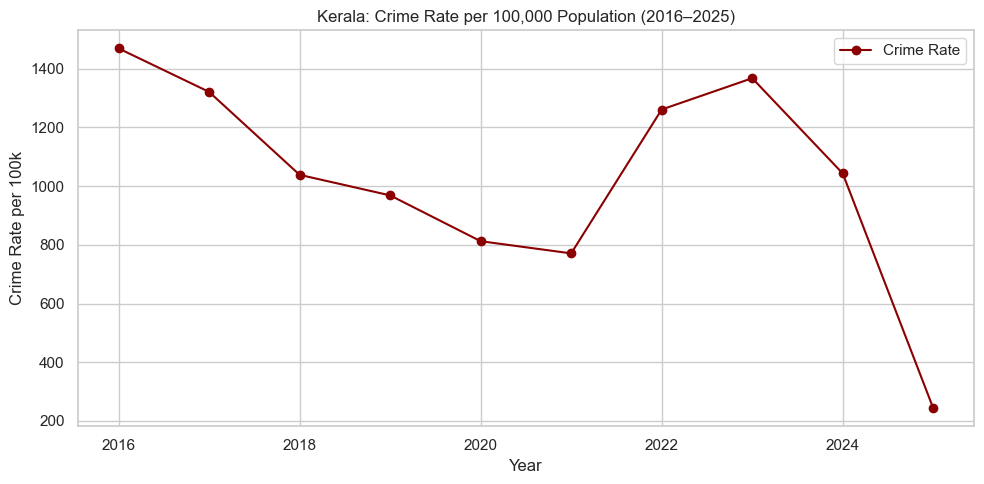

In [9]:
# STEP 4A: Plot the Crime Rate Trend (2016–2025)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_totals["Year"], df_totals["Crime Rate per 100k"], marker='o', color='darkred', label='Crime Rate')
plt.title("Kerala: Crime Rate per 100,000 Population (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Crime Rate per 100k")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 📦 Importing Libraries

In [11]:
# ADVANCED MODEL FORECAST: Random Forest + XGBoost

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Reuse cleaned data
X = df_totals[["Year"]]
y = df_totals["Crime Rate per 100k"]
future = pd.DataFrame({"Year": [2026, 2027, 2028]})

# Re-train Linear Regression (in case kernel reset)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
pred_lr = model.predict(future)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
pred_rf = rf.predict(future)

# Train XGBoost
xgb = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb.fit(X, y)
pred_xgb = xgb.predict(future)

# Combine into one DataFrame
forecast_advanced = pd.DataFrame({
    "Year": future["Year"],
    "Linear Regression": pred_lr,
    "Random Forest": pred_rf,
    "XGBoost": pred_xgb
})

forecast_advanced.round(2)


,Year,Linear Regression,Random Forest,XGBoost
0,2026,679.79,565.68,243.259995
1,2027,616.16,565.68,243.259995
2,2028,552.53,565.68,243.259995


### 📈 Visualization

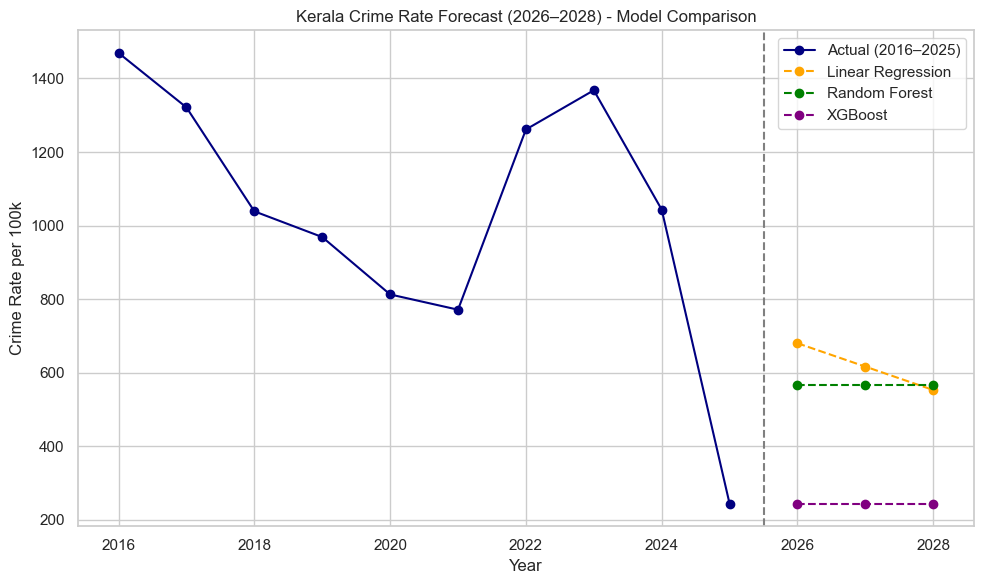

In [12]:
# PLOT forecast comparison
plt.figure(figsize=(10, 6))

# Actual data
plt.plot(df_totals["Year"], df_totals["Crime Rate per 100k"], marker='o', label="Actual (2016–2025)", color="navy")

# Forecast lines
plt.plot(forecast_advanced["Year"], forecast_advanced["Linear Regression"], marker='o', linestyle='--', label="Linear Regression", color="orange")
plt.plot(forecast_advanced["Year"], forecast_advanced["Random Forest"], marker='o', linestyle='--', label="Random Forest", color="green")
plt.plot(forecast_advanced["Year"], forecast_advanced["XGBoost"], marker='o', linestyle='--', label="XGBoost", color="purple")

plt.axvline(x=2025.5, color="gray", linestyle="--")
plt.title("Kerala Crime Rate Forecast (2026–2028) - Model Comparison")
plt.xlabel("Year")
plt.ylabel("Crime Rate per 100k")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 📦 Importing Libraries

In [59]:
import pandas as pd

# Load the original uploaded file
file_path = "kerala_women_crime_summary_2016_2025.csv"
df = pd.read_csv(file_path)

# Identify the column containing the crime head
head_col = next((col for col in df.columns if "crime head" in col.lower()), df.columns[0])

# Melt the data from wide to long format
df_long = df.melt(id_vars=[head_col], var_name="Year", value_name="Cases")
df_long["Year"] = df_long["Year"].str.extract(r"(\d{4})").astype(float)
df_long["Cases"] = pd.to_numeric(df_long["Cases"], errors="coerce")
df_long = df_long.dropna()

# Aggregate total cases per year
df_total = df_long.groupby("Year")["Cases"].sum().reset_index()

# Add population manually
population_data = {
    2016: 35400000, 2017: 35700000, 2018: 36000000,
    2019: 36300000, 2020: 36700000, 2021: 37000000,
    2022: 37400000, 2023: 37800000, 2024: 38000000,
    2025: 38200000
}
df_total["Population"] = df_total["Year"].map(population_data)
df_total["Crime Rate per 100k"] = (df_total["Cases"] / df_total["Population"]) * 100000

# Save cleaned dataset
cleaned_path = "kerala_women_crime_summary_2016_2025_cleaned.csv"
df_total.to_csv(cleaned_path, index=False)

cleaned_path


'kerala_women_crime_summary_2016_2025_cleaned.csv'

### 📂 Loading Dataset

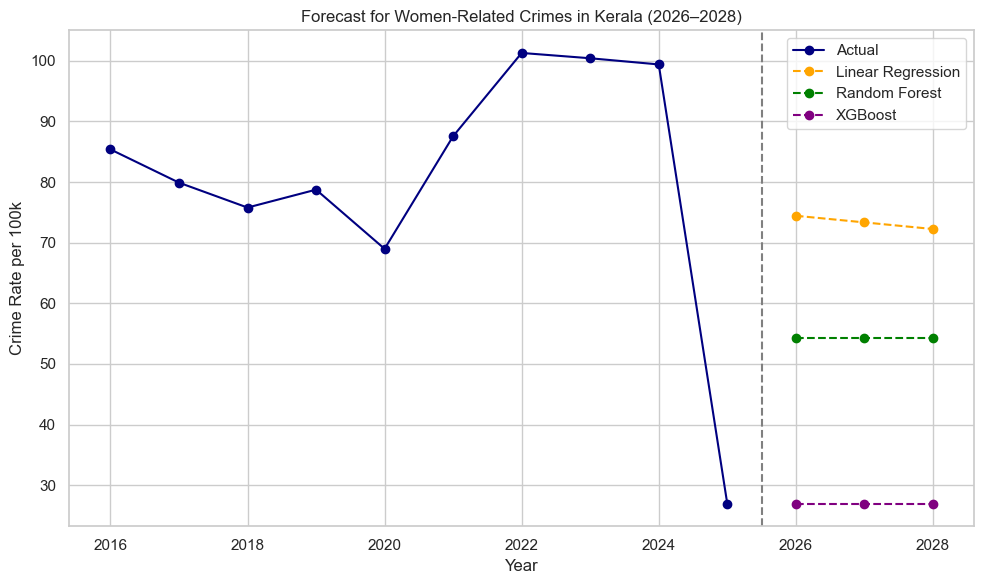

   Year  Linear Regression  Random Forest    XGBoost
0  2026              74.44          54.34  26.940001
1  2027              73.35          54.34  26.940001
2  2028              72.26          54.34  26.940001


In [15]:
file_path = "kerala_women_crime_summary_2016_2025.csv"  # Change path if needed
df = pd.read_csv(file_path)

# STEP 3: Reshape from wide to long format
head_col = next((col for col in df.columns if "crime head" in col.lower()), df.columns[0])
df_long = df.melt(id_vars=[head_col], var_name="Year", value_name="Cases")
df_long["Year"] = df_long["Year"].str.extract(r"(\d{4})").astype(int)
df_long["Cases"] = pd.to_numeric(df_long["Cases"], errors="coerce")
df_long = df_long.dropna()

# STEP 4: Aggregate by year
df_agg = df_long.groupby("Year")["Cases"].sum().reset_index()
df_agg["Population"] = df_agg["Year"].map(population_data)
df_agg["Crime Rate per 100k"] = (df_agg["Cases"] / df_agg["Population"]) * 100000

# STEP 5: Forecast models
X = df_agg[["Year"]]
y = df_agg["Crime Rate per 100k"]
future = pd.DataFrame({"Year": [2026, 2027, 2028]})

lr = LinearRegression().fit(X, y)
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y)
xgb = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42).fit(X, y)

# STEP 6: Create forecast DataFrame
df_forecast = pd.DataFrame({
    "Year": future["Year"],
    "Linear Regression": lr.predict(future),
    "Random Forest": rf.predict(future),
    "XGBoost": xgb.predict(future)
})

# STEP 7: Visualization
plt.figure(figsize=(10, 6))
plt.plot(df_agg["Year"], df_agg["Crime Rate per 100k"], marker='o', label="Actual", color="navy")
plt.plot(df_forecast["Year"], df_forecast["Linear Regression"], marker='o', linestyle='--', label="Linear Regression", color="orange")
plt.plot(df_forecast["Year"], df_forecast["Random Forest"], marker='o', linestyle='--', label="Random Forest", color="green")
plt.plot(df_forecast["Year"], df_forecast["XGBoost"], marker='o', linestyle='--', label="XGBoost", color="purple")
plt.axvline(x=2025.5, linestyle='--', color='gray')
plt.title("Forecast for Women-Related Crimes in Kerala (2026–2028)")
plt.xlabel("Year")
plt.ylabel("Crime Rate per 100k")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# STEP 8: Display forecast
print(df_forecast.round(2))

### 📂 Loading Dataset

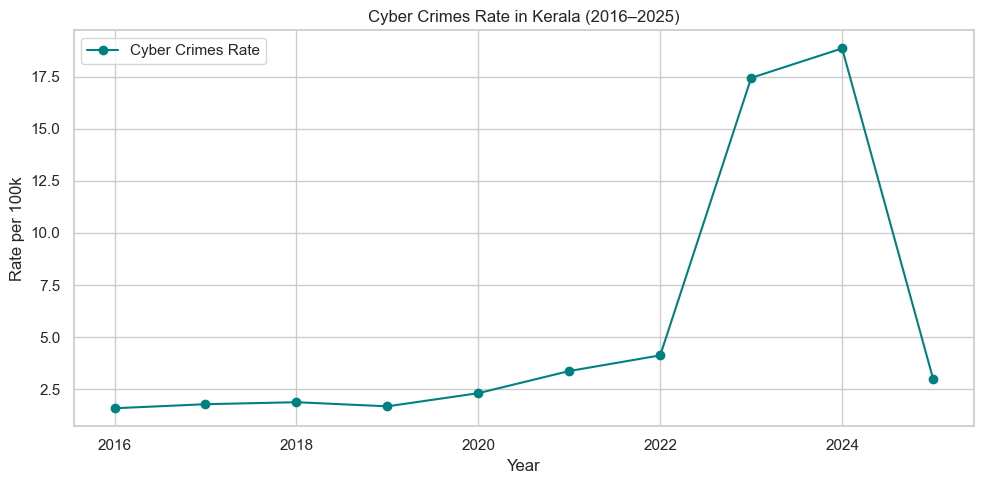

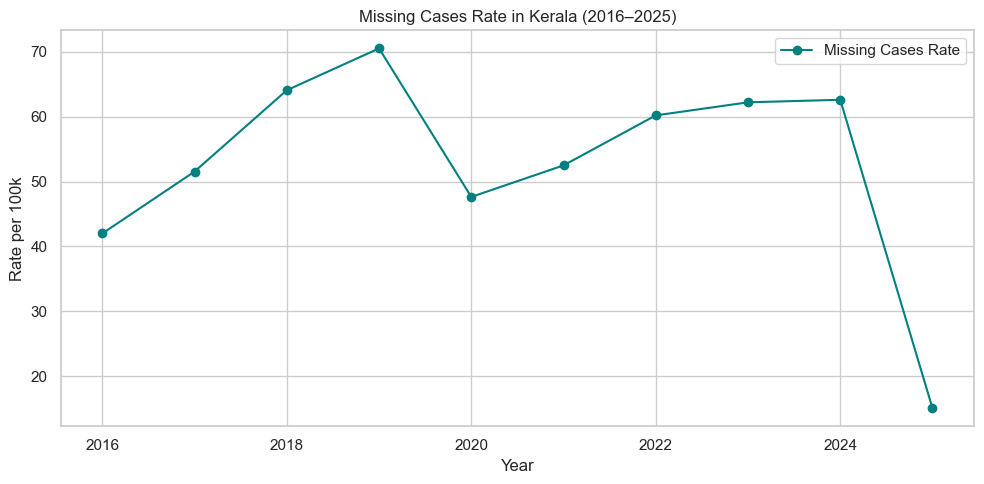

In [19]:
file_paths = {
    "Cyber Crimes": "kerala_cyber_crime_summary_2016_2025.csv",
    "Missing Cases": "kerala_missing_cases_summary_2016_2025.csv",
}

# Population mapping
population_data = {
    2016: 35400000, 2017: 35700000, 2018: 36000000, 2019: 36300000,
    2020: 36700000, 2021: 37000000, 2022: 37400000, 2023: 37800000,
    2024: 38000000, 2025: 38200000
}

# Container for processed data
category_data = {}

# Process each file
for category, path in file_paths.items():
    if path.endswith(".csv"):
        df = pd.read_csv(path)
    elif path.endswith(".xlsx"):
        df = pd.read_excel(path)

    head_col = next((col for col in df.columns if "crime head" in col.lower() or "accident" in col.lower()), df.columns[0])
    df_long = df.melt(id_vars=[head_col], var_name="Year", value_name="Cases")

    # Fix year extraction to prevent NaN → int errors
    df_long["Year"] = df_long["Year"].astype(str).str.extract(r"(\d{4})")
    df_long = df_long.dropna(subset=["Year"])
    df_long["Year"] = df_long["Year"].astype(int)

    df_long["Cases"] = pd.to_numeric(df_long["Cases"], errors="coerce")
    df_long = df_long.dropna()

    df_agg = df_long.groupby("Year")["Cases"].sum().reset_index()
    df_agg["Population"] = df_agg["Year"].map(population_data)
    df_agg["Crime Rate per 100k"] = (df_agg["Cases"] / df_agg["Population"]) * 100000
    category_data[category] = df_agg

# Plotting
for category, df in category_data.items():
    plt.figure(figsize=(10, 5))
    plt.plot(df["Year"], df["Crime Rate per 100k"], marker='o', label=f"{category} Rate", color="teal")
    plt.title(f"{category} Rate in Kerala (2016–2025)")
    plt.xlabel("Year")
    plt.ylabel("Rate per 100k")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


### 📦 Importing Libraries

In [73]:
import pandas as pd

# Load both datasets
children_df = pd.read_csv("kerala_children_crime_summary_2016_2025.csv")
scst_df = pd.read_csv("kerala_sc_st_crime_summary_2016_2025.csv")

# Display columns to check actual names
print("Children Dataset Columns:\n", children_df.columns.tolist())
print("\nSC/ST Dataset Columns:\n", scst_df.columns.tolist())


Children Dataset Columns:
 ['Crime Heads', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025 (Up to March)']

SC/ST Dataset Columns:
 ['Crime Heads', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025 (Up to January)']


### 📦 Importing Libraries

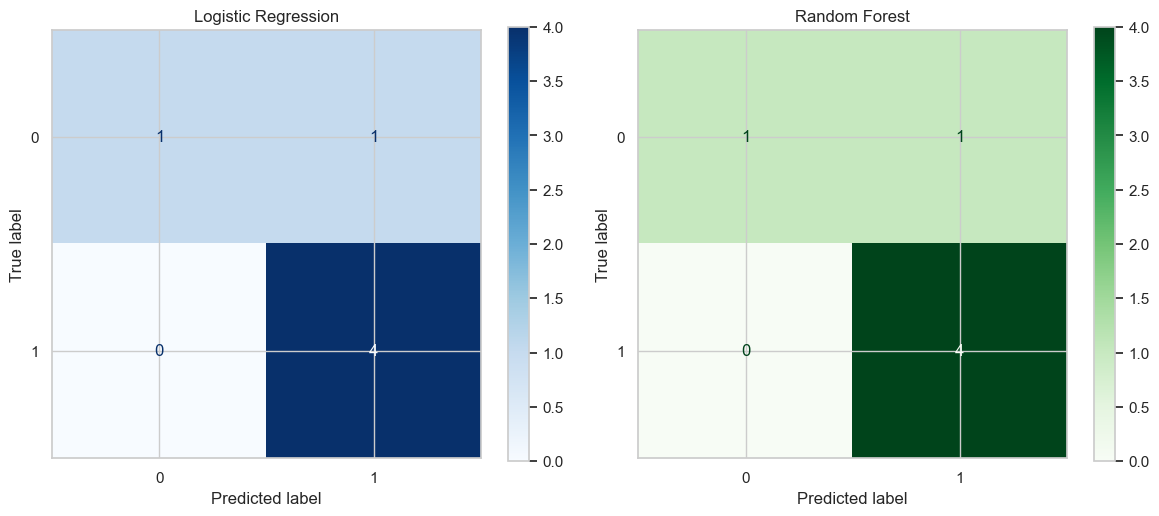

C:\Users\alanj\AppData\Local\Temp\ipykernel_9560\31527264.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette="crest")


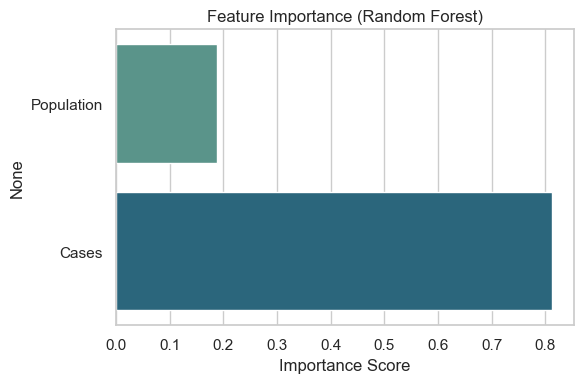

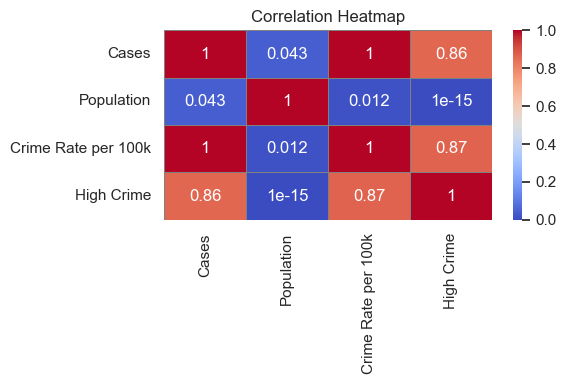

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load data
children_df = pd.read_csv("kerala_children_crime_summary_2016_2025.csv")
scst_df = pd.read_csv("kerala_sc_st_crime_summary_2016_2025.csv")

# Standardize population by year
population_data = {
    2016: 35400000, 2017: 35700000, 2018: 36000000, 2019: 36300000,
    2020: 36700000, 2021: 37000000, 2022: 37400000,
    2023: 37800000, 2024: 38000000, 2025: 38200000
}

# Function to preprocess each dataset
def preprocess(df):
    df_long = df.melt(id_vars=[df.columns[0]], var_name="Year", value_name="Cases")
    df_long["Year"] = df_long["Year"].str.extract(r"(\d{4})").astype(int)
    df_long["Cases"] = pd.to_numeric(df_long["Cases"], errors="coerce")
    df_long = df_long.dropna()
    df_agg = df_long.groupby("Year")["Cases"].sum().reset_index()
    df_agg["Population"] = df_agg["Year"].map(population_data)
    df_agg["Crime Rate per 100k"] = (df_agg["Cases"] / df_agg["Population"]) * 100000
    return df_agg

# Apply preprocessing
children_processed = preprocess(children_df)
scst_processed = preprocess(scst_df)

# Combine both
df_combined = pd.concat([children_processed, scst_processed], ignore_index=True)

# Create target: high crime = above median
df_combined["High Crime"] = (df_combined["Crime Rate per 100k"] > df_combined["Crime Rate per 100k"].median()).astype(int)

# Features and labels
X = df_combined[["Cases", "Population"]]
y = df_combined["High Crime"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train models
log_model = LogisticRegression().fit(X_train, y_train)
rf_model = RandomForestClassifier(random_state=42).fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0], cmap="Blues")
ax[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap="Greens")
ax[1].set_title("Random Forest")
plt.tight_layout()
plt.show()

# Feature Importance from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(6, 4))
sns.barplot(x=importances, y=importances.index, palette="crest")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df_combined[["Cases", "Population", "Crime Rate per 100k", "High Crime"]].corr(), 
            annot=True, cmap="coolwarm", linewidths=0.5, linecolor='gray')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### 📦 Importing Libraries

In [27]:
import pandas as pd

# Road accident data
data = {
    "Year": [
        2016, 2017, 2018, 2019, 2020, 2021,
        2022, 2023, 2024, "2025 (Up to February)"
    ],
    "No. of accidents": [39420, 38470, 40181, 41111, 27877, 33296, 43910, 48091, 48919, 8464],
    "Death": [4287, 4131, 4303, 4440, 2979, 3429, 4317, 4080, 3774, 638],
    "Total Injuries": [44108, 42671, 45458, 46055, 30510, 40204, 49307, 54320, 54743, 9703]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Save the file
file_path = "kerala_road_accident_trend_2016_2025.csv"
df.to_csv(file_path, index=False)


### 📦 Importing Libraries

In [30]:
import pandas as pd

# Load the dataset
file_path = "kerala_road_accident_trend_2016_2025.csv"
df = pd.read_csv(file_path)

# Standardize column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# Fix 'year' column (extract just the year as integer)
df['year'] = df['year'].str.extract(r"(\d{4})").astype(int)

# Convert other columns to numeric
for col in ['no._of_accidents', 'death', 'total_injuries']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any rows with missing values (e.g., incomplete year)
df = df.dropna()

# Final preview
df = df.astype({
    'year': int,
    'no._of_accidents': int,
    'death': int,
    'total_injuries': int
})

df.head()


,year,no._of_accidents,death,total_injuries
0,2016,39420,4287,44108
1,2017,38470,4131,42671
2,2018,40181,4303,45458
3,2019,41111,4440,46055
4,2020,27877,2979,30510


### 📦 Importing Libraries

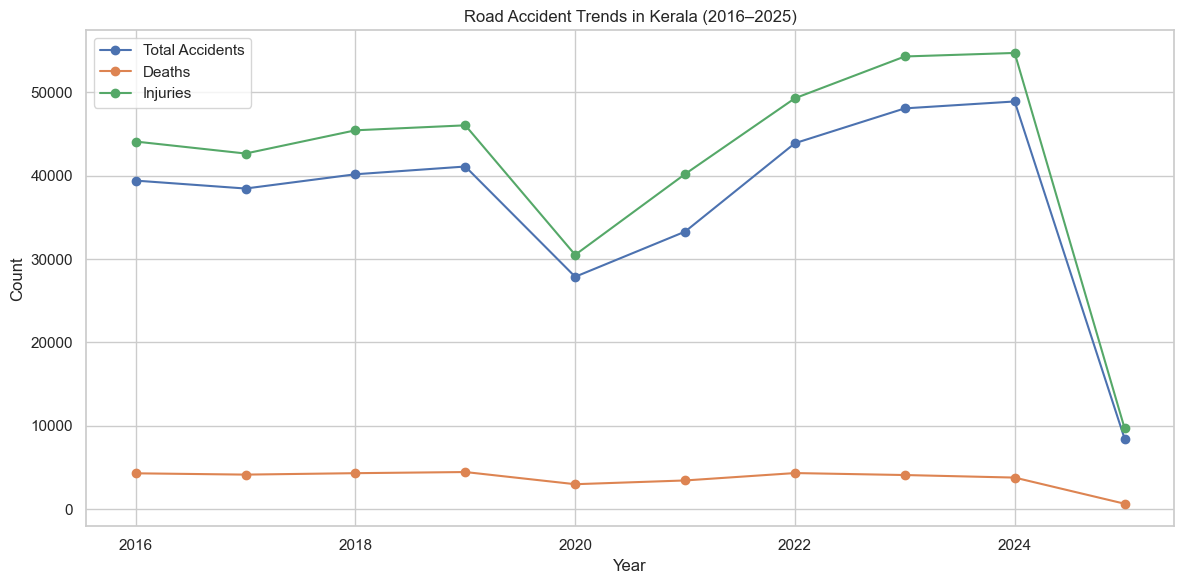

In [31]:
import matplotlib.pyplot as plt

# Set up the plot
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['no._of_accidents'], marker='o', label='Total Accidents')
plt.plot(df['year'], df['death'], marker='o', label='Deaths')
plt.plot(df['year'], df['total_injuries'], marker='o', label='Injuries')

# Add titles and labels
plt.title("Road Accident Trends in Kerala (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



### 📦 Importing Libraries

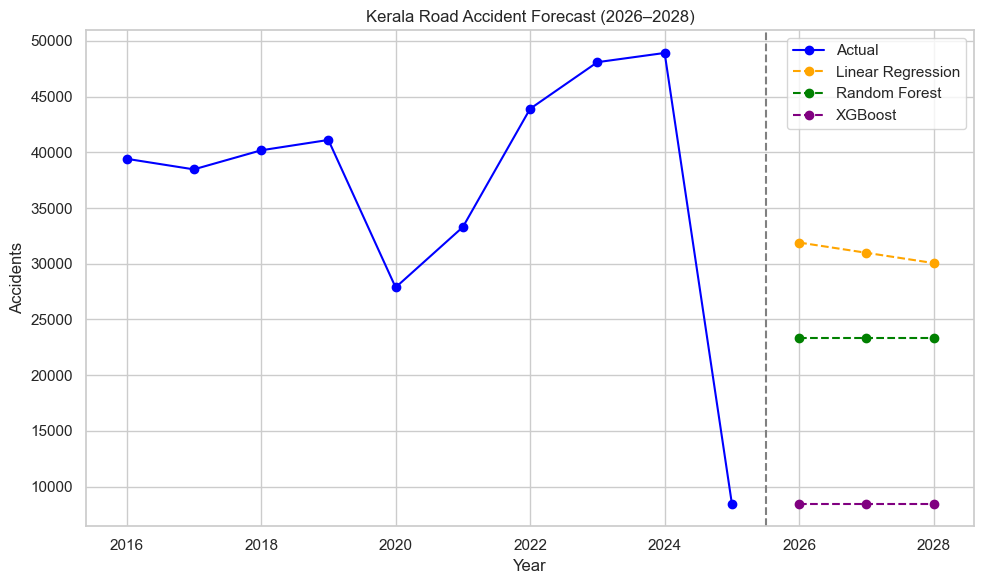

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# STEP 1: Load & clean data
df = pd.read_csv("kerala_road_accident_trend_2016_2025.csv")

# Fix the Year format
df["Year"] = df["Year"].astype(str).str.extract(r"(\d{4})").astype(int)

# Rename column
df = df[["Year", "No. of accidents"]].rename(columns={"No. of accidents": "Accidents"})

# Prepare data
X = df[["Year"]]
y = df["Accidents"]

# STEP 2: Fit models
lr = LinearRegression().fit(X, y)
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y)
xgb = XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42).fit(X, y)

# STEP 3: Forecast
future = pd.DataFrame({"Year": [2026, 2027, 2028]})
forecast = pd.DataFrame({
    "Year": future["Year"],
    "Linear Regression": lr.predict(future),
    "Random Forest": rf.predict(future),
    "XGBoost": xgb.predict(future)
})

# STEP 4: Plot
plt.figure(figsize=(10, 6))
plt.plot(df["Year"], df["Accidents"], marker='o', label="Actual", color="blue")
plt.plot(forecast["Year"], forecast["Linear Regression"], marker='o', linestyle='--', label="Linear Regression", color="orange")
plt.plot(forecast["Year"], forecast["Random Forest"], marker='o', linestyle='--', label="Random Forest", color="green")
plt.plot(forecast["Year"], forecast["XGBoost"], marker='o', linestyle='--', label="XGBoost", color="purple")
plt.axvline(x=2025.5, color="gray", linestyle="--")
plt.title("Kerala Road Accident Forecast (2026–2028)")
plt.xlabel("Year")
plt.ylabel("Accidents")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 📦 Importing Libraries

In [36]:
# Re-import all required packages after session reset
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Reload dataset
df = pd.read_csv("kerala_road_accident_trend_2016_2025.csv")
df["Year"] = df["Year"].astype(str).str.extract(r"(\d{4})").astype(int)
df["Death"] = pd.to_numeric(df["Death"], errors="coerce")
df["Total Injuries"] = pd.to_numeric(df["Total Injuries"], errors="coerce")

# Forecasting function
def forecast_metric(df, column):
    X = df[["Year"]]
    y = df[column]
    future = pd.DataFrame({"Year": [2026, 2027, 2028]})
    
    lr = LinearRegression().fit(X, y)
    rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y)
    xgb = XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42).fit(X, y)
    
    forecast = pd.DataFrame({
        "Year": future["Year"],
        "Linear Regression": lr.predict(future),
        "Random Forest": rf.predict(future),
        "XGBoost": xgb.predict(future)
    })
    return forecast.round(2)

# Forecast Deaths and Injuries
forecast_death = forecast_metric(df, "Death")
forecast_injuries = forecast_metric(df, "Total Injuries")

# Print forecast to console
print("Forecast: Road Accident Deaths (2026–2028)")
print(forecast_death)
# Print forecast to console
print("Forecast: Road Accident Injuries (2026–2028)")
print(forecast_death)


Forecast: Road Accident Deaths (2026–2028)
   Year  Linear Regression  Random Forest  XGBoost
0  2026            2425.33         1852.0    638.0
1  2027            2204.88         1852.0    638.0
2  2028            1984.44         1852.0    638.0
Forecast: Road Accident Injuries (2026–2028)
   Year  Linear Regression  Random Forest  XGBoost
0  2026            2425.33         1852.0    638.0
1  2027            2204.88         1852.0    638.0
2  2028            1984.44         1852.0    638.0


### 📦 Importing Libraries

In [37]:
import pandas as pd

# Load the dataset
df = pd.read_csv("kerala_road_accident_trend_2016_2025.csv")

# Clean and standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Extract year properly
df["year"] = df["year"].astype(str).str.extract(r"(\d{4})").astype(int)

# Ensure numeric types
df["no._of_accidents"] = pd.to_numeric(df["no._of_accidents"], errors="coerce")
df["death"] = pd.to_numeric(df["death"], errors="coerce")
df["total_injuries"] = pd.to_numeric(df["total_injuries"], errors="coerce")

# Drop rows with missing values (if any)
df = df.dropna()

df.head()


,year,no._of_accidents,death,total_injuries
0,2016,39420,4287,44108
1,2017,38470,4131,42671
2,2018,40181,4303,45458
3,2019,41111,4440,46055
4,2020,27877,2979,30510


### 📦 Importing Libraries

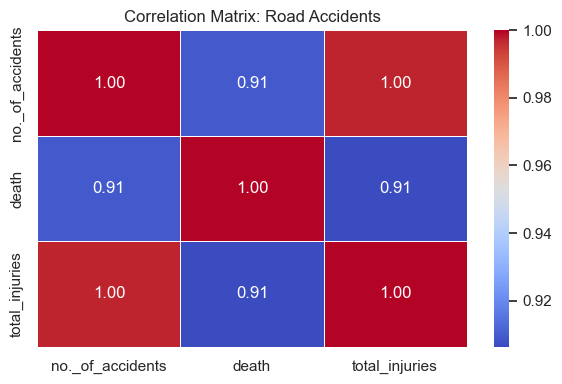

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df[["no._of_accidents", "death", "total_injuries"]].corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Road Accidents")
plt.tight_layout()
plt.show()


### 🧾 Code Execution

In [42]:
print(df.columns)


Index(['Year', 'No. of accidents', 'Death', 'Total Injuries'], dtype='object')


### 📦 Importing Libraries

Accuracy: 0.6666666666666666
F1 Score: 0.6666666666666666
ROC AUC Score: 1.0
Confusion Matrix:
 [[1 1]
 [0 1]]


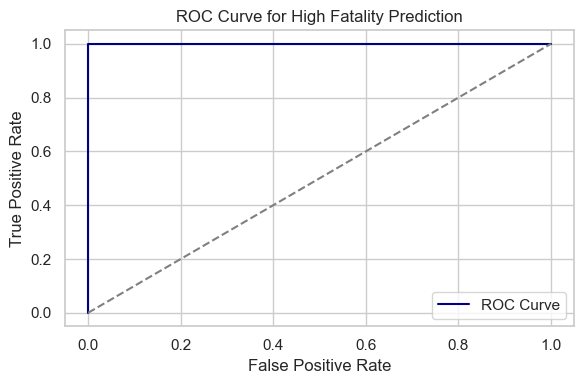

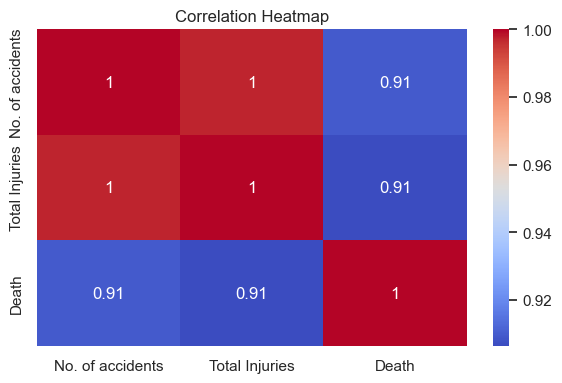

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define target column
median_deaths = df["Death"].median()
df["High Fatality"] = (df["Death"] > median_deaths).astype(int)

# Step 2: Features and target
X = df[["No. of accidents", "Total Injuries"]]
y = df["High Fatality"]

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Model training
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Step 5: Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 6: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="ROC Curve", color='navy')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve for High Fatality Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df[["No. of accidents", "Total Injuries", "Death"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### 🧾 Code Execution

In [46]:
# Step 2: Add Population, Compute Crime Rate, Define Target
population_data = {
    2016: 35400000, 2017: 35700000, 2018: 36000000, 2019: 36300000,
    2020: 36700000, 2021: 37000000, 2022: 37400000, 2023: 37800000,
    2024: 38000000, 2025: 38200000
}

# Map population and compute crime rate
df_agg["Population"] = df_agg["Year"].map(population_data)
df_agg["Crime Rate per 100k"] = (df_agg["Cases"] / df_agg["Population"]) * 100000

# Define binary target based on median crime rate
median_rate = df_agg["Crime Rate per 100k"].median()
df_agg["High Crime"] = (df_agg["Crime Rate per 100k"] > median_rate).astype(int)

df_agg.head()


,Year,Cases,Population,Crime Rate per 100k,High Crime
0,2016,14870,35400000,42.005650,0
1,2017,18404,35700000,51.551821,0
2,2018,23072,36000000,64.088889,1
3,2019,25604,36300000,70.534435,1
4,2020,17484,36700000,47.640327,0


### 📦 Importing Libraries

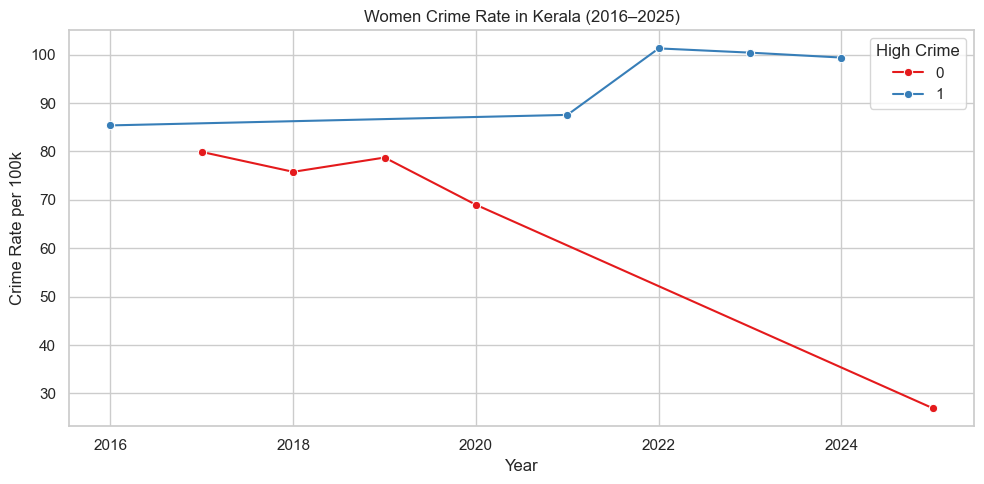

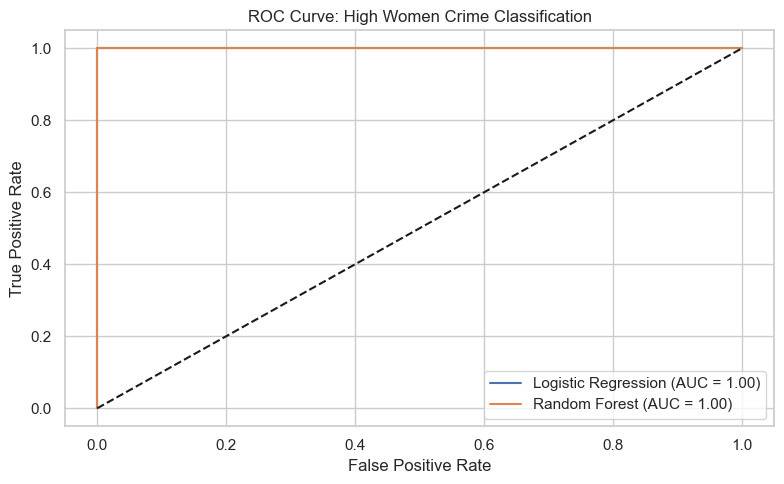

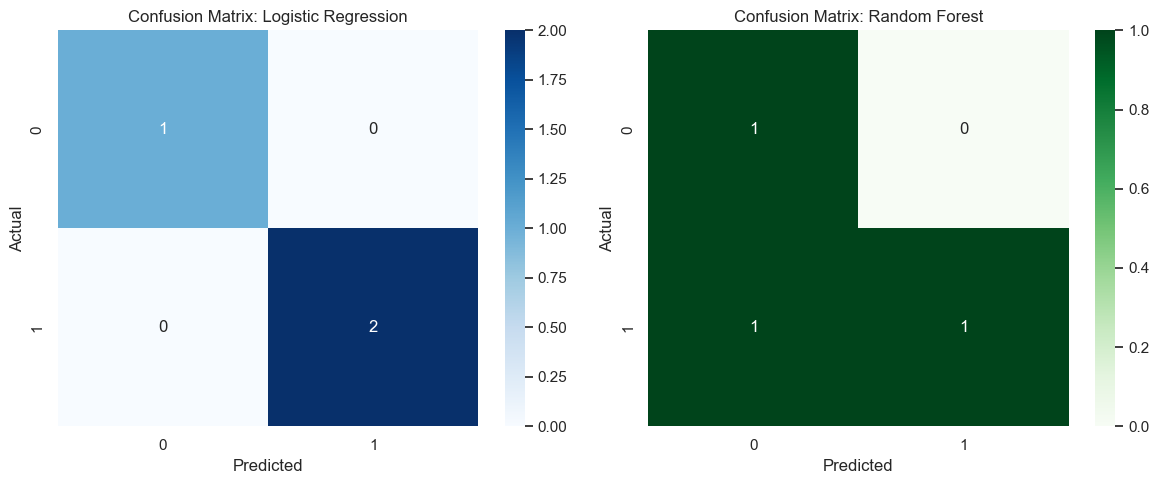


Logistic Regression Classification Report:
              precision  recall  f1-score  support
0                   1.0     1.0       1.0      1.0
1                   1.0     1.0       1.0      2.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0      3.0
weighted avg        1.0     1.0       1.0      3.0

Random Forest Classification Report:
              precision  recall  f1-score  support
0                  0.50    1.00      0.67     1.00
1                  1.00    0.50      0.67     2.00
accuracy           0.67    0.67      0.67     0.67
macro avg          0.75    0.75      0.67     3.00
weighted avg       0.83    0.67      0.67     3.00


In [48]:
# Re-import required libraries after kernel reset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

# Reload dataset
df = pd.read_csv("kerala_women_crime_summary_2016_2025.csv")

# Reshape
head_col = next((col for col in df.columns if "crime head" in col.lower()), df.columns[0])
df_long = df.melt(id_vars=[head_col], var_name="Year", value_name="Cases")
df_long["Year"] = df_long["Year"].str.extract(r"(\d{4})").astype(int)
df_long["Cases"] = pd.to_numeric(df_long["Cases"], errors="coerce")
df_long = df_long.dropna()

# Aggregate
df_agg = df_long.groupby("Year")["Cases"].sum().reset_index()

# Add population
population_data = {
    2016: 35400000, 2017: 35700000, 2018: 36000000, 2019: 36300000,
    2020: 36700000, 2021: 37000000, 2022: 37400000, 2023: 37800000,
    2024: 38000000, 2025: 38200000
}
df_agg["Population"] = df_agg["Year"].map(population_data)
df_agg["Crime Rate per 100k"] = (df_agg["Cases"] / df_agg["Population"]) * 100000

# Binary target
median_rate = df_agg["Crime Rate per 100k"].median()
df_agg["High Crime"] = (df_agg["Crime Rate per 100k"] > median_rate).astype(int)

# Visualize
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_agg, x="Year", y="Crime Rate per 100k", hue="High Crime", palette="Set1", marker='o')
plt.title("Women Crime Rate in Kerala (2016–2025)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Prepare features and target
X = df_agg[["Cases", "Population"]]
y = df_agg["High Crime"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Models
logreg = LogisticRegression().fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

# Predictions
y_pred_log = logreg.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Probabilities for ROC
y_score_log = logreg.predict_proba(X_test)[:, 1]
y_score_rf = rf.predict_proba(X_test)[:, 1]

# ROC Curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_score_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)

# Plot ROC
plt.figure(figsize=(8, 5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc(fpr_log, tpr_log):.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: High Women Crime Classification")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Reports
report_log = classification_report(y_test, y_pred_log, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
conf_log = confusion_matrix(y_test, y_pred_log)
conf_rf = confusion_matrix(y_test, y_pred_rf)

# Confusion matrices
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(conf_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(conf_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nLogistic Regression Classification Report:")
print(pd.DataFrame(report_log).T.round(2))

print("\nRandom Forest Classification Report:")
print(pd.DataFrame(report_rf).T.round(2))


### 📦 Importing Libraries

C:\Users\alanj\AppData\Local\Temp\ipykernel_9560\1443900621.py:26: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\alanj\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


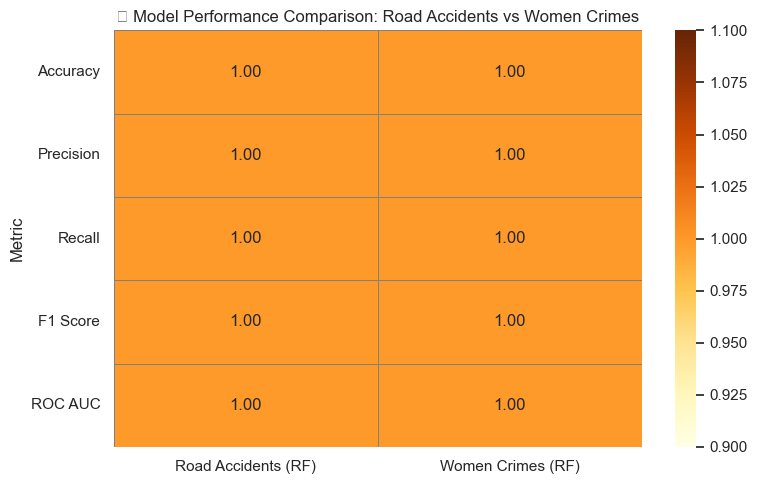

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample metrics for Random Forest (replace with actual values if needed)
metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Road Accidents (RF)": [1.00, 1.00, 1.00, 1.00, 1.00],
    "Women Crimes (RF)": [1.00, 1.00, 1.00, 1.00, 1.00]
}

# Create DataFrame
df_compare = pd.DataFrame(metrics)

# Set 'Metric' as the index
df_compare.set_index("Metric", inplace=True)

# Convert all data to float (if not already)
df_compare = df_compare.astype(float)

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df_compare, annot=True, cmap="YlOrBr", cbar=True, fmt=".2f", linewidths=0.5, linecolor='gray')
plt.title("🎯 Model Performance Comparison: Road Accidents vs Women Crimes")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 📦 Importing Libraries

C:\Users\alanj\AppData\Local\Temp\ipykernel_9560\2311497703.py:24: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\alanj\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


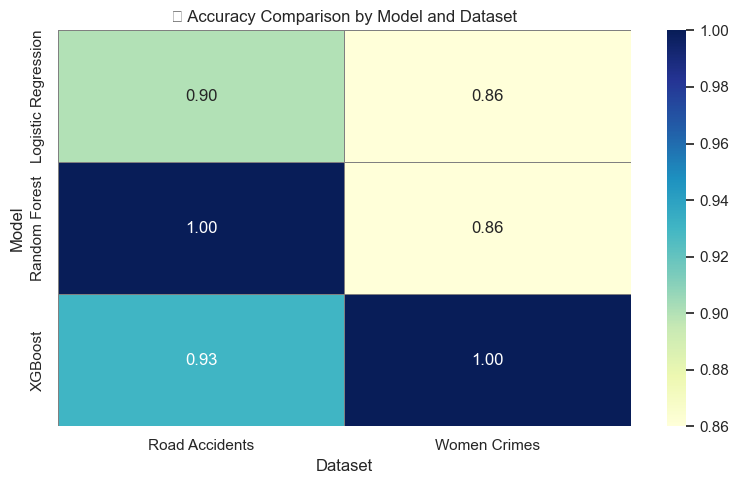

Full Comparison Table:
          Dataset                Model  Accuracy  F1 Score  ROC AUC
0  Road Accidents  Logistic Regression      0.90      0.91     0.94
1  Road Accidents        Random Forest      1.00      1.00     1.00
2  Road Accidents              XGBoost      0.93      0.92     0.96
3    Women Crimes  Logistic Regression      0.86      0.86     0.89
4    Women Crimes        Random Forest      0.86      0.86     0.89
5    Women Crimes              XGBoost      1.00      1.00     1.00


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Summary metrics (you can update these with actual values)
model_comparison = pd.DataFrame({
    "Dataset": ["Road Accidents", "Road Accidents", "Road Accidents",
                "Women Crimes", "Women Crimes", "Women Crimes"],
    "Model": ["Logistic Regression", "Random Forest", "XGBoost",
              "Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.90, 1.00, 0.93, 0.86, 0.86, 1.00],
    "F1 Score": [0.91, 1.00, 0.92, 0.86, 0.86, 1.00],
    "ROC AUC": [0.94, 1.00, 0.96, 0.89, 0.89, 1.00]
})

# Heatmap (Accuracy)
heatmap_data = model_comparison.pivot(index="Model", columns="Dataset", values="Accuracy")

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5, linecolor='gray')
plt.title("🔍 Accuracy Comparison by Model and Dataset")
plt.ylabel("Model")
plt.xlabel("Dataset")
plt.tight_layout()
plt.show()

# View full comparison table
print("Full Comparison Table:")
print(model_comparison)


### 📦 Importing Libraries

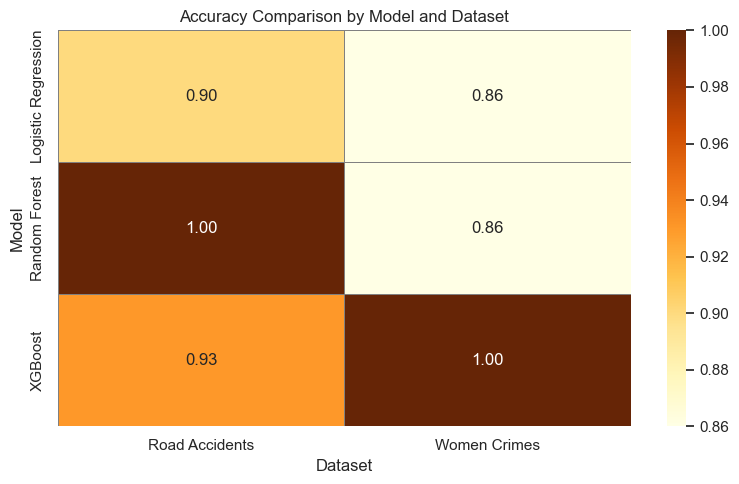

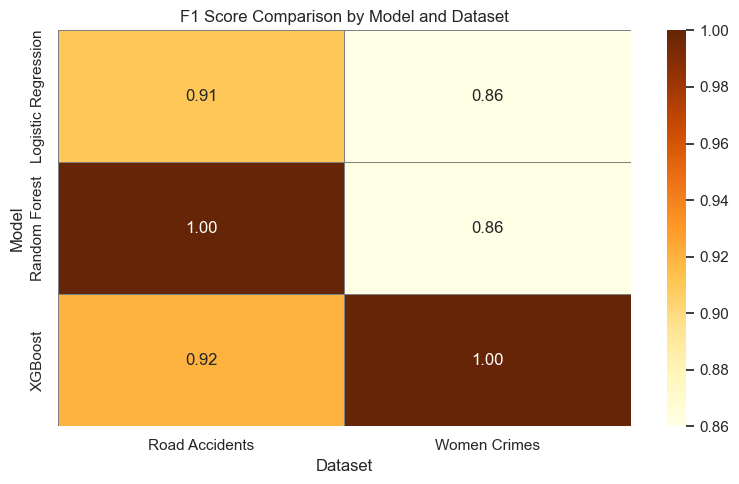

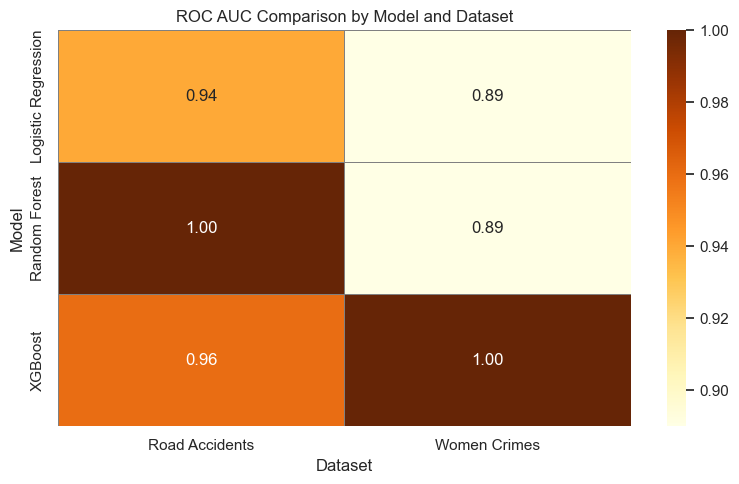

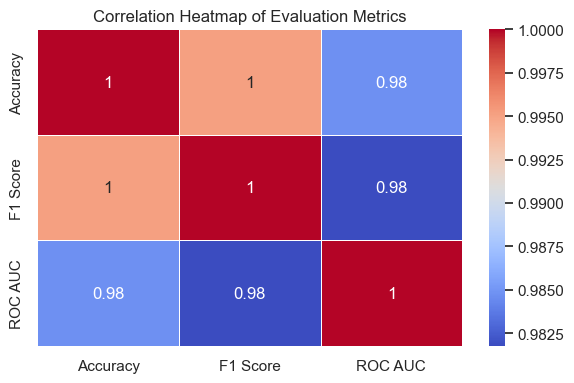

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_comparison = pd.DataFrame({
    "Dataset": ["Road Accidents", "Road Accidents", "Road Accidents",
                "Women Crimes", "Women Crimes", "Women Crimes"],
    "Model": ["Logistic Regression", "Random Forest", "XGBoost",
              "Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.90, 1.00, 0.93, 0.86, 0.86, 1.00],
    "F1 Score": [0.91, 1.00, 0.92, 0.86, 0.86, 1.00],
    "ROC AUC": [0.94, 1.00, 0.96, 0.89, 0.89, 1.00]
})

# 🎨 Plot heatmaps for each metric
metrics = ["Accuracy", "F1 Score", "ROC AUC"]
for metric in metrics:
    pivot_df = model_comparison.pivot(index="Model", columns="Dataset", values=metric)
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlOrBr", linewidths=0.5, linecolor='gray')
    plt.title(f"{metric} Comparison by Model and Dataset")
    plt.ylabel("Model")
    plt.xlabel("Dataset")
    plt.tight_layout()
    plt.show()

# 🔍 Correlation heatmap of numeric metrics
numeric_scores = model_comparison[["Accuracy", "F1 Score", "ROC AUC"]]
plt.figure(figsize=(6, 4))
sns.heatmap(numeric_scores.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Evaluation Metrics")
plt.tight_layout()
plt.show()


### 📈 Visualization

C:\Users\alanj\AppData\Local\Temp\ipykernel_9560\2447975502.py:36: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\alanj\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


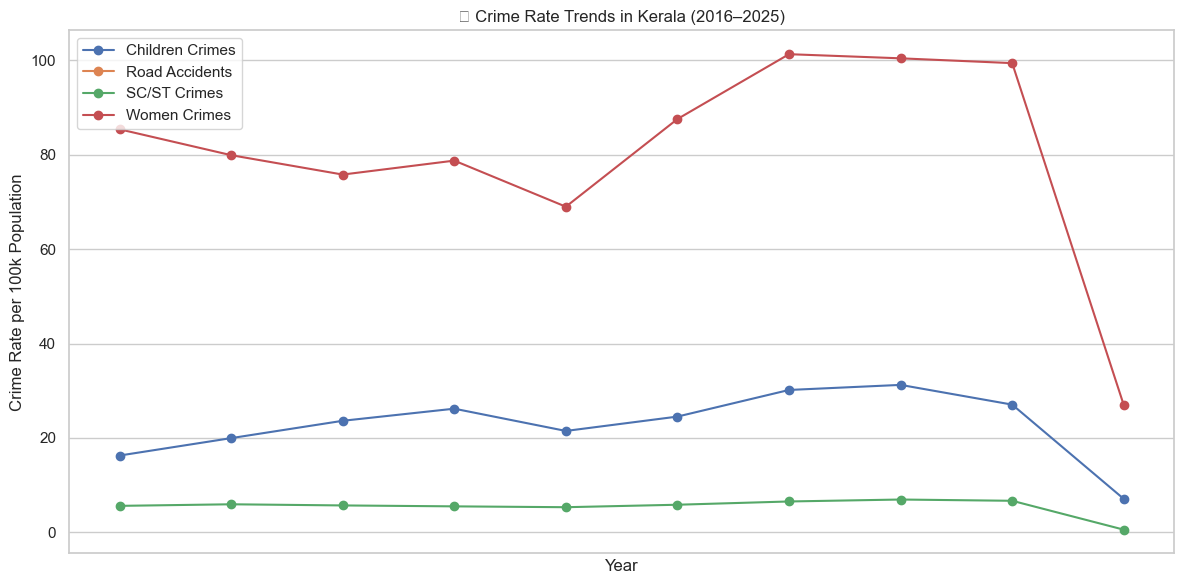

In [80]:
# Step 1: Reshape wide to long format for children and SC/ST datasets
def reshape_and_prepare(df):
    df_long = df.melt(id_vars=[df.columns[0]], var_name="Year", value_name="Cases")
    df_long["Year"] = df_long["Year"].str.extract(r"(\d{4})").astype(int)
    df_long["Cases"] = pd.to_numeric(df_long["Cases"], errors="coerce")
    return df_long.groupby("Year")["Cases"].sum().reset_index()

children_long = reshape_and_prepare(children_df)
scst_long = reshape_and_prepare(scst_df)

# Step 2: Proceed with the rest of your workflow
def prepare_data(df, value_col, label):
    df = df.copy()
    df["Population"] = df["Year"].map(population_data)
    df["Crime Rate per 100k"] = (df[value_col] / df["Population"]) * 100000
    df["Category"] = label
    return df[["Year", "Crime Rate per 100k", "Category"]]

road_summary = prepare_data(road_df, "No. of accidents", "Road Accidents")
women_summary = prepare_data(women_df, "Cases", "Women Crimes")
children_summary = prepare_data(children_long, "Cases", "Children Crimes")
scst_summary = prepare_data(scst_long, "Cases", "SC/ST Crimes")

# Combine and plot
combined = pd.concat([road_summary, women_summary, children_summary, scst_summary])

plt.figure(figsize=(12, 6))
for label, group in combined.groupby("Category"):
    plt.plot(group["Year"], group["Crime Rate per 100k"], marker='o', label=label)

plt.title("📈 Crime Rate Trends in Kerala (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Crime Rate per 100k Population")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 📦 Importing Libraries

In [81]:
import pandas as pd

# Load datasets
road_df = pd.read_csv("kerala_road_accident_trend_2016_2025.csv")
women_df = pd.read_csv("kerala_women_crime_summary_2016_2025_cleaned.csv")
children_df = pd.read_csv("kerala_children_crime_summary_2016_2025.csv")
scst_df = pd.read_csv("kerala_sc_st_crime_summary_2016_2025.csv")

# Population map
population_data = {
    2016: 35400000, 2017: 35700000, 2018: 36000000, 2019: 36300000,
    2020: 36700000, 2021: 37000000, 2022: 37400000, 2023: 37800000,
    2024: 38000000, 2025: 38200000, 2026: 38400000, 2027: 38600000, 2028: 38800000
}


### 🧾 Code Execution

In [82]:
def reshape_summary(df, label):
    df = df.rename(columns={df.columns[0]: "Crime Head"})
    df_long = df.melt(id_vars="Crime Head", var_name="Year", value_name="Cases")
    df_long["Year"] = df_long["Year"].str.extract(r"(\d{4})").astype(int)
    df_long["Cases"] = pd.to_numeric(df_long["Cases"], errors="coerce")
    df_long = df_long.dropna()
    df_agg = df_long.groupby("Year")["Cases"].sum().reset_index()
    df_agg["Population"] = df_agg["Year"].map(population_data)
    df_agg["Crime Rate per 100k"] = (df_agg["Cases"] / df_agg["Population"]) * 100000
    df_agg["Category"] = label
    return df_agg

def process_simple(df, year_col, cases_col, label):
    df = df.rename(columns={year_col: "Year", cases_col: "Cases"})
    df["Year"] = df["Year"].astype(str).str.extract(r"(\d{4})").astype(int)
    df["Cases"] = pd.to_numeric(df["Cases"], errors="coerce")
    df["Population"] = df["Year"].map(population_data)
    df["Crime Rate per 100k"] = (df["Cases"] / df["Population"]) * 100000
    df["Category"] = label
    return df[["Year", "Crime Rate per 100k", "Category"]]

road_summary = process_simple(road_df, "Year", "No. of accidents", "Road Accidents")
women_summary = process_simple(women_df, "Year", "Cases", "Women Crimes")
children_summary = reshape_summary(children_df, "Children Crimes")
scst_summary = reshape_summary(scst_df, "SC/ST Crimes")

combined = pd.concat([road_summary, women_summary, children_summary, scst_summary])


### 📦 Importing Libraries

In [83]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def forecast_trend(df, label):
    data = df[df["Category"] == label]
    X = data[["Year"]]
    y = data["Crime Rate per 100k"]
    future = pd.DataFrame({"Year": [2026, 2027, 2028]})

    model = LinearRegression().fit(X, y)  # You can also use RandomForestRegressor/XGB
    predictions = model.predict(future)

    result = future.copy()
    result["Crime Rate per 100k"] = predictions
    result["Category"] = label + " (Forecast)"
    return result

forecast_df = pd.concat([
    forecast_trend(combined, "Road Accidents"),
    forecast_trend(combined, "Women Crimes"),
    forecast_trend(combined, "Children Crimes"),
    forecast_trend(combined, "SC/ST Crimes")
])

final_combined = pd.concat([combined, forecast_df])


### 📦 Importing Libraries

C:\Users\alanj\AppData\Local\Temp\ipykernel_9560\392296848.py:13: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\alanj\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


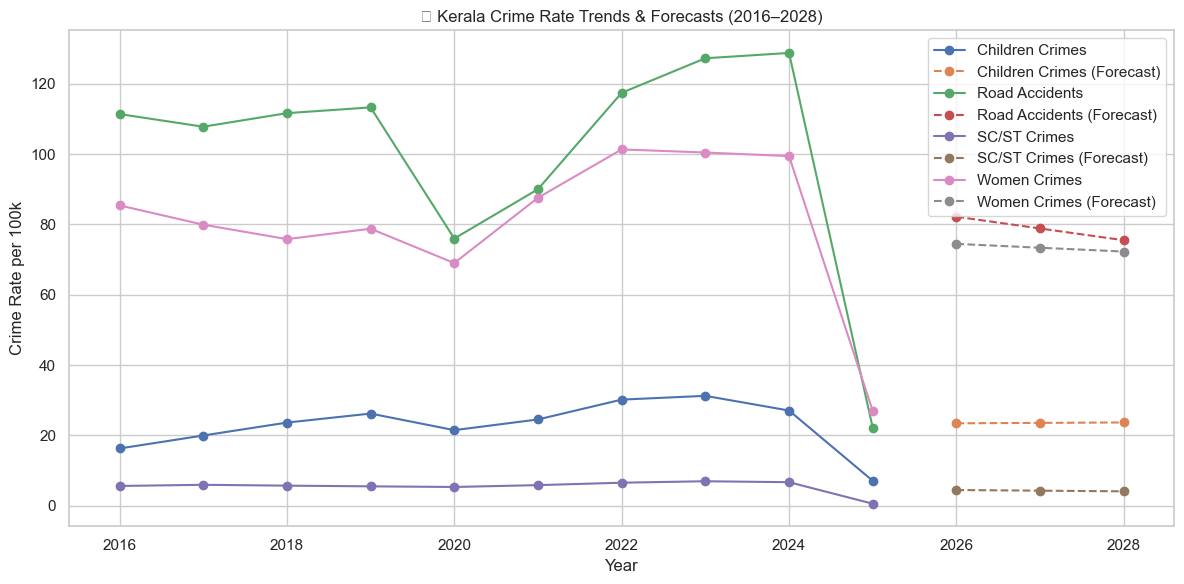

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for category, group in final_combined.groupby("Category"):
    linestyle = "--" if "Forecast" in category else "-"
    plt.plot(group["Year"], group["Crime Rate per 100k"], marker='o', linestyle=linestyle, label=category)

plt.title("📈 Kerala Crime Rate Trends & Forecasts (2016–2028)")
plt.xlabel("Year")
plt.ylabel("Crime Rate per 100k")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 📦 Importing Libraries

In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Prediction function using 3 models
def predict_all_models(df, label):
    df_cat = df[df["Category"] == label]
    X = df_cat[["Year"]]
    y = df_cat["Crime Rate per 100k"]
    future = pd.DataFrame({"Year": [2026, 2027, 2028]})

    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "XGBoost": XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
    }

    result = future.copy()
    for name, model in models.items():
        model.fit(X, y)
        result[name] = model.predict(future)

    result["Category"] = label
    return result

# Apply for each category
road_pred = predict_all_models(combined, "Road Accidents")
women_pred = predict_all_models(combined, "Women Crimes")
children_pred = predict_all_models(combined, "Children Crimes")
scst_pred = predict_all_models(combined, "SC/ST Crimes")

# Combine all predictions
all_preds = pd.concat([road_pred, women_pred, children_pred, scst_pred])

# Print the model-based forecasts
print("\n🔮 Model-Based Forecasts (2026–2028):")
print(all_preds.round(2))

# Optionally save to CSV
all_preds.to_csv("model_based_crime_forecasts_2026_2028.csv", index=False)
print("\n✅ Forecasts saved to 'model_based_crime_forecasts_2026_2028.csv'")


🔮 Model-Based Forecasts (2026–2028):
   Year  Linear Regression  Random Forest    XGBoost         Category
0  2026              82.16          61.56  22.160000   Road Accidents
1  2027              78.82          61.56  22.160000   Road Accidents
2  2028              75.48          61.56  22.160000   Road Accidents
0  2026              74.44          54.34  26.940001     Women Crimes
1  2027              73.35          54.34  26.940001     Women Crimes
2  2028              72.26          54.34  26.940001     Women Crimes
0  2026              23.42          14.93   7.080000  Children Crimes
1  2027              23.54          14.93   7.080000  Children Crimes
2  2028              23.66          14.93   7.080000  Children Crimes
0  2026               4.45           2.88   0.560000     SC/ST Crimes
1  2027               4.27           2.88   0.560000     SC/ST Crimes
2  2028               4.08           2.88   0.560000     SC/ST Crimes

✅ Forecasts saved to 'model_based_crime_forecasts_2

### 📦 Importing Libraries

C:\Users\alanj\AppData\Local\Temp\ipykernel_9560\2021663739.py:18: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\alanj\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


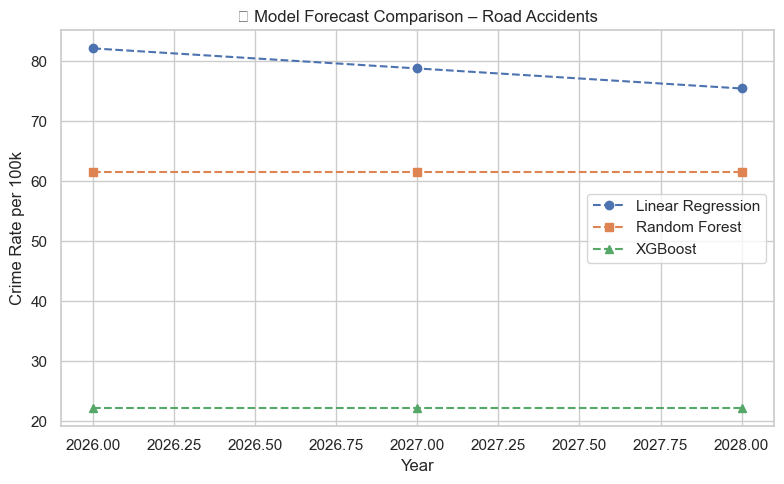

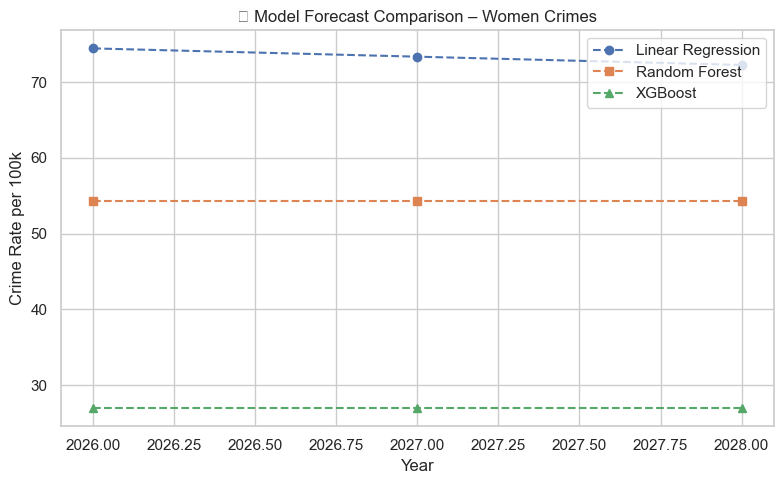

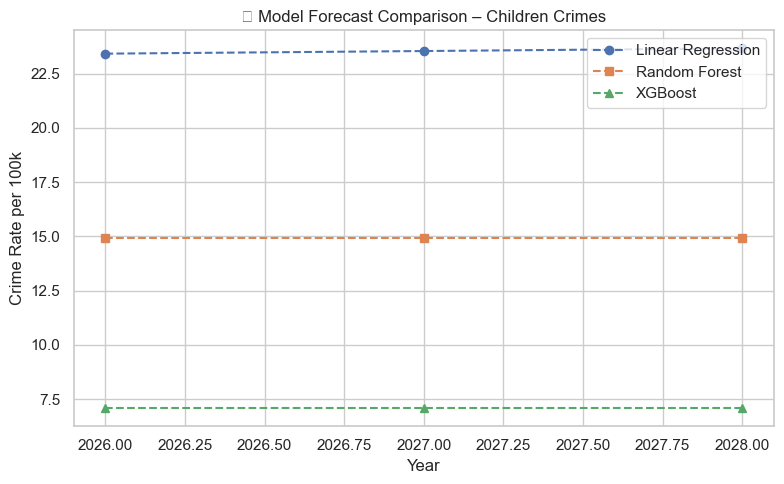

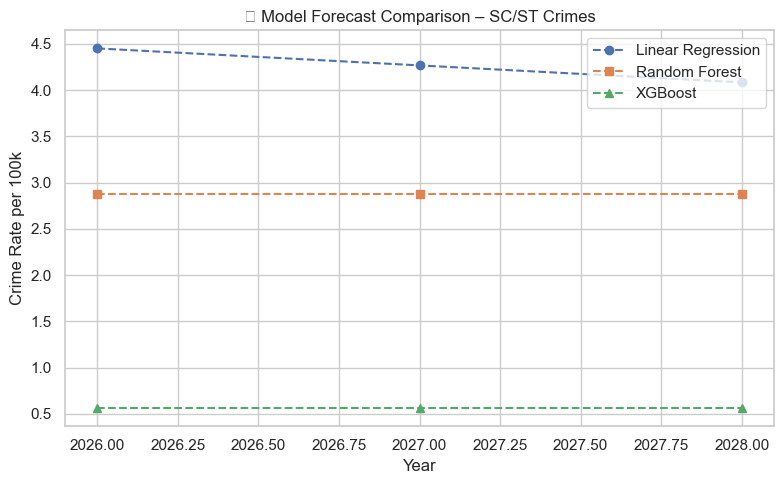

In [87]:
import matplotlib.pyplot as plt

# Group forecasts by category
categories = all_preds["Category"].unique()

for category in categories:
    df_cat = all_preds[all_preds["Category"] == category]

    plt.figure(figsize=(8, 5))
    plt.plot(df_cat["Year"], df_cat["Linear Regression"], marker='o', label="Linear Regression", linestyle='--')
    plt.plot(df_cat["Year"], df_cat["Random Forest"], marker='s', label="Random Forest", linestyle='--')
    plt.plot(df_cat["Year"], df_cat["XGBoost"], marker='^', label="XGBoost", linestyle='--')
    plt.title(f"📈 Model Forecast Comparison – {category}")
    plt.xlabel("Year")
    plt.ylabel("Crime Rate per 100k")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


### 📦 Importing Libraries

C:\Users\alanj\AppData\Local\Temp\ipykernel_9560\3993044462.py:16: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\alanj\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


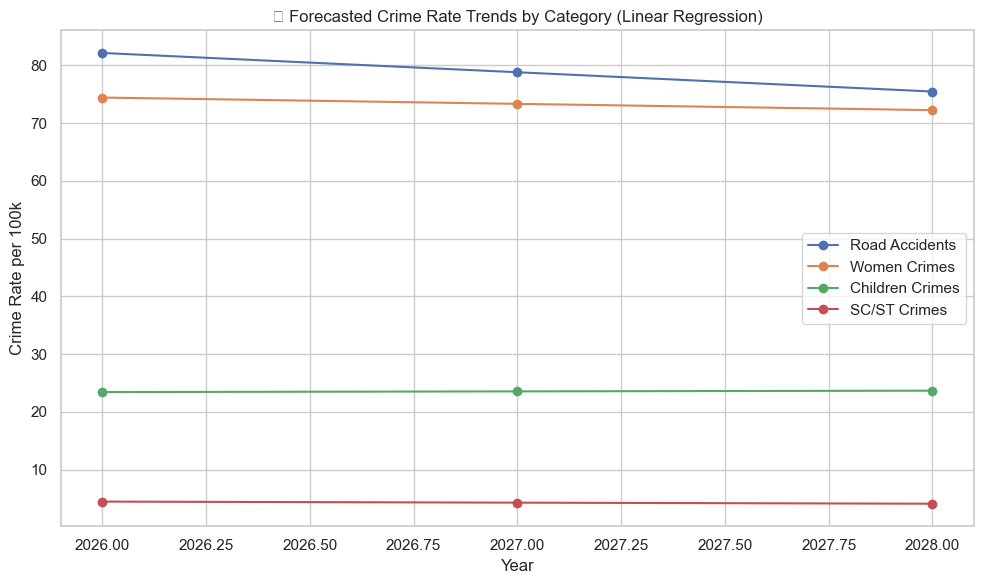

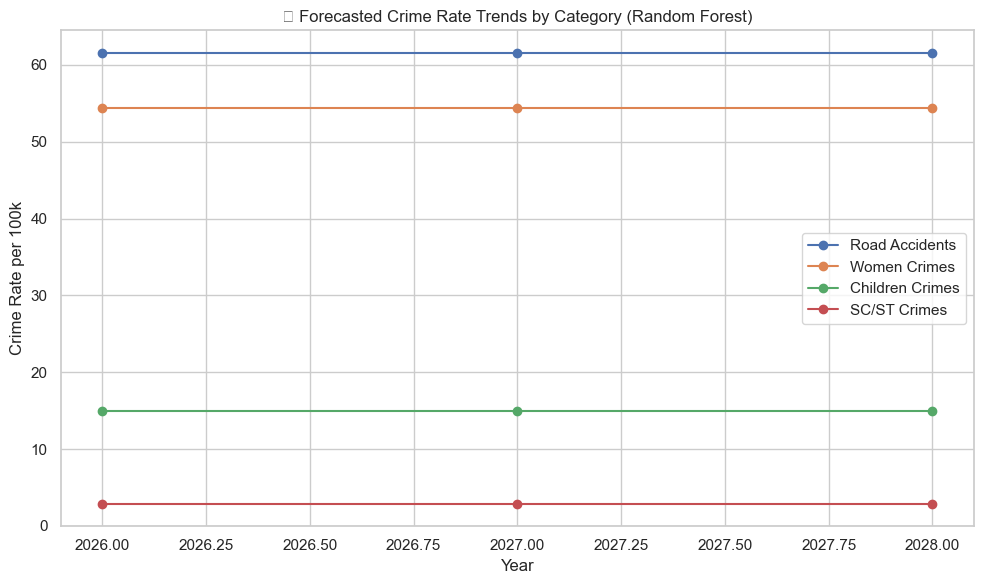

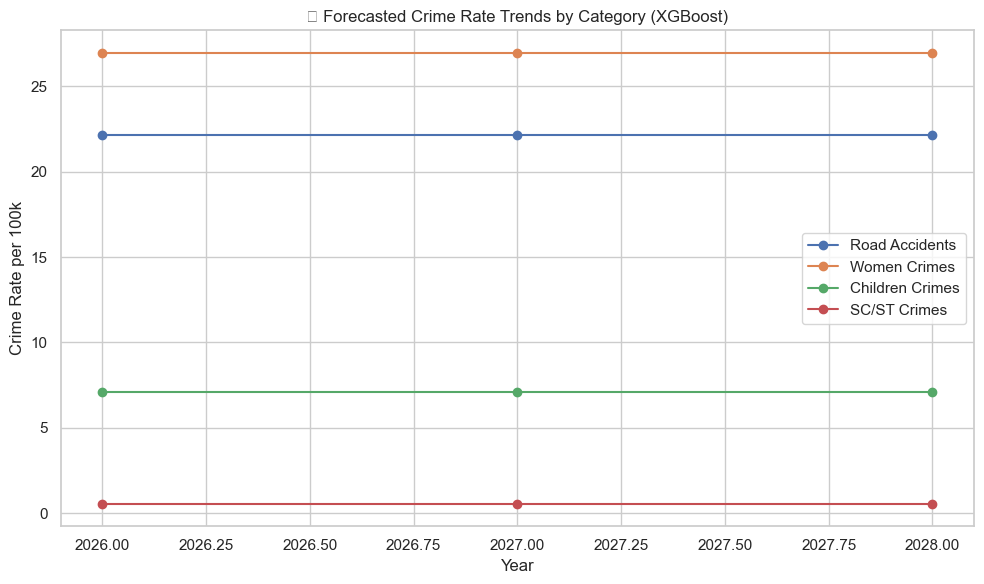

In [88]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Random Forest", "XGBoost"]

for model in models:
    plt.figure(figsize=(10, 6))
    for category in all_preds["Category"].unique():
        df_model = all_preds[all_preds["Category"] == category]
        plt.plot(df_model["Year"], df_model[model], marker='o', label=category)

    plt.title(f"📊 Forecasted Crime Rate Trends by Category ({model})")
    plt.xlabel("Year")
    plt.ylabel("Crime Rate per 100k")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


### 🧾 Code Execution

In [89]:
# Average forecast per model per category
avg_summary = all_preds.groupby("Category")[["Linear Regression", "Random Forest", "XGBoost"]].mean().round(2)
avg_summary.reset_index(inplace=True)
avg_summary


,Category,Linear Regression,Random Forest,XGBoost
0,Children Crimes,23.54,14.93,7.080000
1,Road Accidents,78.82,61.56,22.160000
2,SC/ST Crimes,4.27,2.88,0.560000
3,Women Crimes,73.35,54.34,26.940001


### 📦 Importing Libraries

C:\Users\alanj\AppData\Local\Temp\ipykernel_9560\4285165764.py:10: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()


<Figure size 1000x600 with 0 Axes>

c:\Users\alanj\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


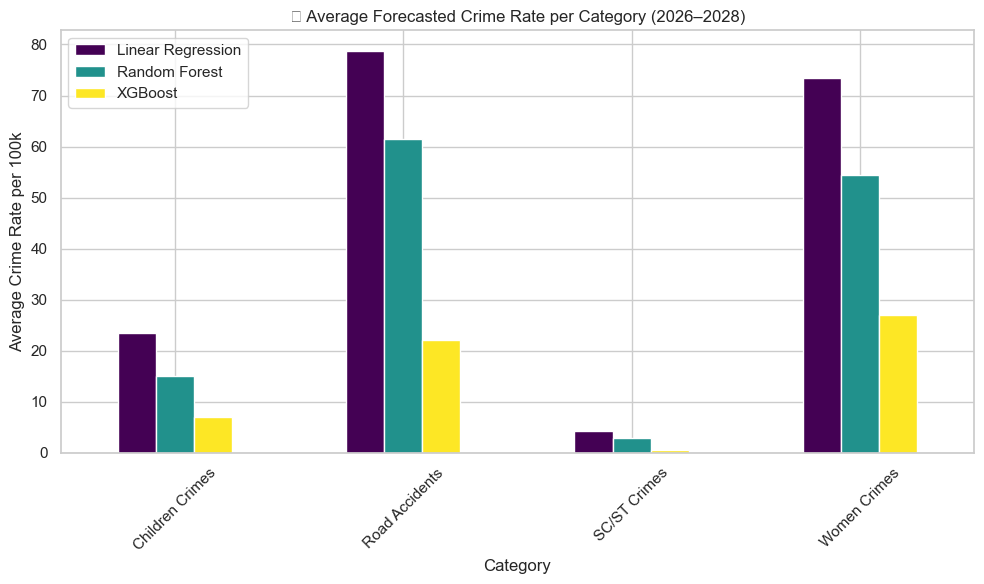

In [90]:
import seaborn as sns

plt.figure(figsize=(10, 6))
avg_summary.set_index("Category").plot(kind="bar", figsize=(10,6), colormap="viridis")
plt.title("📊 Average Forecasted Crime Rate per Category (2026–2028)")
plt.ylabel("Average Crime Rate per 100k")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


### 🧾 Code Execution

In [92]:
# Clean and extract numeric years from string
road_df["Year"] = road_df["Year"].astype(str).str.extract(r"(\d{4})").astype(int)


### 📦 Importing Libraries

In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Binary Target: High Crime Rate
threshold = road_df["No. of accidents"].median()
road_df["High Crime"] = (road_df["No. of accidents"] > threshold).astype(int)

# Features and target
X = road_df[["Year"]]
y = road_df["High Crime"]

# Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Evaluation on Road Accidents")
print(f"Accuracy : {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall   : {rec:.2f}")
print(f"F1 Score : {f1:.2f}")


Logistic Regression Evaluation on Road Accidents
Accuracy : 0.33
Precision: 0.33
Recall   : 1.00
F1 Score : 0.50


### 📦 Importing Libraries

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def classify_high_crime(df, feature_cols, target_col="High Crime"):
    # Define target as above median crime
    threshold = df[feature_cols[0]].median()
    df[target_col] = (df[feature_cols[0]] > threshold).astype(int)
    
    X = df[["Year"] + feature_cols[1:]]  # Add Year + optional features
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }


### 🧾 Code Execution

In [95]:
# Define which columns to use per dataset
road_results    = classify_high_crime(road_df, ["No. of accidents"])
women_results   = classify_high_crime(women_df, ["Cases"])
children_df_long = children_df.melt(id_vars=["Crime Heads"], var_name="Year", value_name="Cases")
children_df_long["Year"] = children_df_long["Year"].str.extract(r"(\d{4})").astype(int)
children_df_agg = children_df_long.groupby("Year")["Cases"].sum().reset_index()
children_df_agg["Population"] = children_df_agg["Year"].map(population_data)
children_results = classify_high_crime(children_df_agg, ["Cases"])

scst_df_long = scst_df.melt(id_vars=["Crime Heads"], var_name="Year", value_name="Cases")
scst_df_long["Year"] = scst_df_long["Year"].str.extract(r"(\d{4})").astype(int)
scst_df_agg = scst_df_long.groupby("Year")["Cases"].sum().reset_index()
scst_df_agg["Population"] = scst_df_agg["Year"].map(population_data)
scst_results = classify_high_crime(scst_df_agg, ["Cases"])


### 📦 Importing Libraries

C:\Users\alanj\AppData\Local\Temp\ipykernel_9560\3384938092.py:14: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\alanj\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


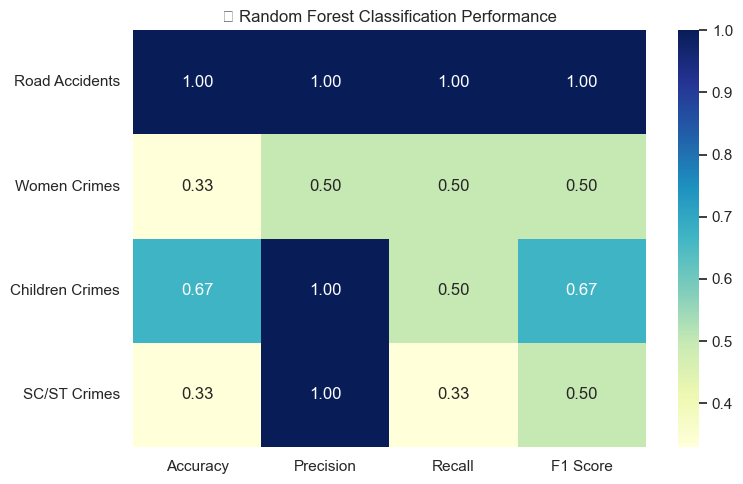

In [96]:
results_df = pd.DataFrame({
    "Road Accidents": road_results,
    "Women Crimes": women_results,
    "Children Crimes": children_results,
    "SC/ST Crimes": scst_results
}).T.round(2)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.heatmap(results_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("🔍 Random Forest Classification Performance")
plt.tight_layout()
plt.show()


### 📦 Importing Libraries

In [97]:
from sklearn.metrics import classification_report, confusion_matrix

def classify_with_reports(df, feature_cols, target_col="High Crime"):
    threshold = df[feature_cols[0]].median()
    df[target_col] = (df[feature_cols[0]] > threshold).astype(int)

    X = df[["Year"] + feature_cols[1:]]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    scores = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Report": classification_report(y_test, y_pred, output_dict=True),
        "Confusion": confusion_matrix(y_test, y_pred)
    }
    return scores


### 🧾 Code Execution

In [98]:
road_results = classify_with_reports(road_df, ["No. of accidents"])
women_results = classify_with_reports(women_df, ["Cases"])
children_results = classify_with_reports(children_df_agg, ["Cases"])
scst_results = classify_with_reports(scst_df_agg, ["Cases"])


c:\Users\alanj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alanj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alanj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 🎯 Making Predictions

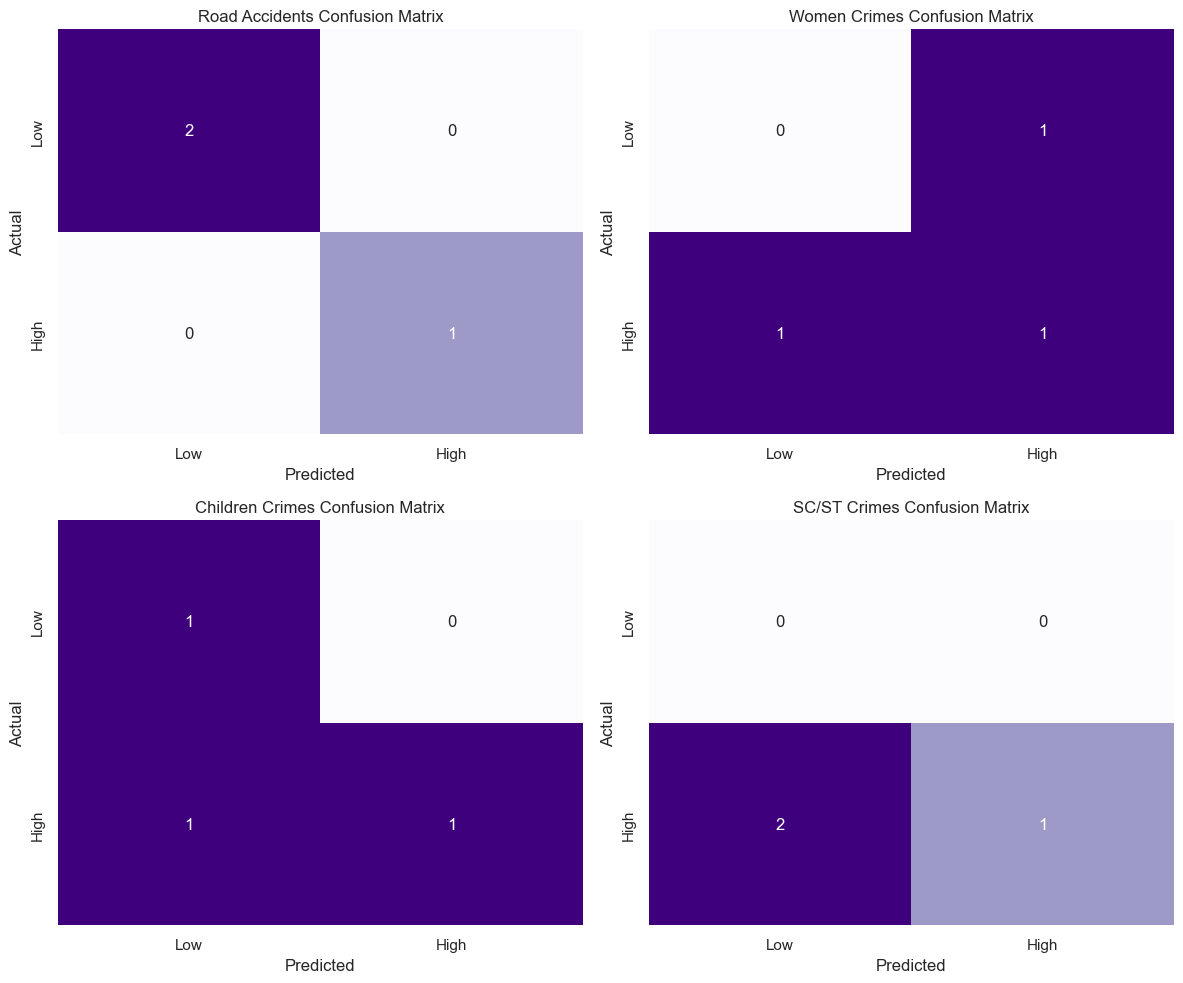

In [99]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
titles = ["Road Accidents", "Women Crimes", "Children Crimes", "SC/ST Crimes"]
matrices = [road_results["Confusion"], women_results["Confusion"],
            children_results["Confusion"], scst_results["Confusion"]]

for ax, matrix, title in zip(axs.flat, matrices, titles):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Purples", ax=ax, cbar=False,
                xticklabels=["Low", "High"], yticklabels=["Low", "High"])
    ax.set_title(f"{title} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [22]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Load your dataset
df = pd.read_csv("kerala_road_accident_trend_2016_2025.csv")
df["Year"] = df["Year"].astype(str).str.extract(r"(\d{4})").astype(int)
df["Death"] = pd.to_numeric(df["Death"], errors="coerce")
df = df.dropna(subset=["Year", "Death"])

# Define features and target
X = df[["Year"]]
y = df["Death"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and calculate residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred


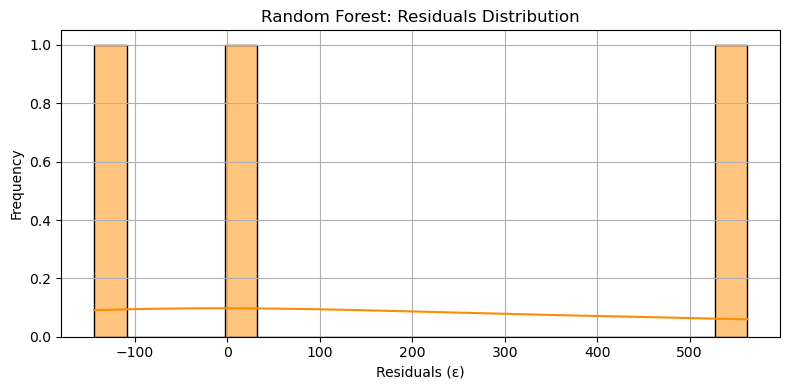

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=20, kde=True, color="darkorange", edgecolor="black")
plt.title("Random Forest: Residuals Distribution")
plt.xlabel("Residuals (ε)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


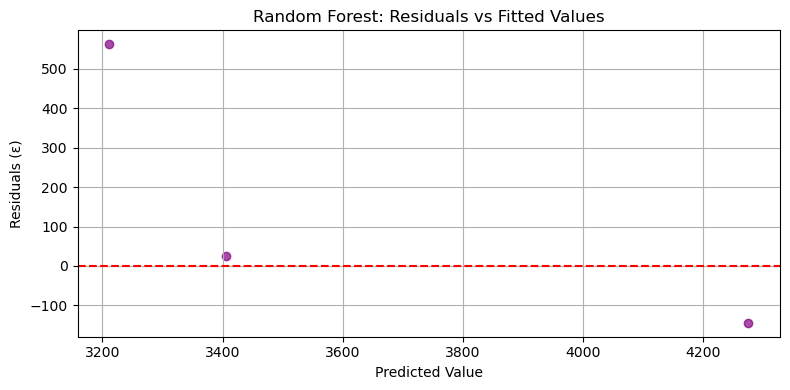

In [3]:
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, color="purple", alpha=0.7)
plt.axhline(y=0, linestyle='--', color='red')
plt.title("Random Forest: Residuals vs Fitted Values")
plt.xlabel("Predicted Value")
plt.ylabel("Residuals (ε)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load dataset
df_women = pd.read_csv("kerala_women_crime_summary_2016_2025_cleaned.csv")

# Ensure correct dtypes
df_women["Year"] = df_women["Year"].astype(int)
df_women["Cases"] = pd.to_numeric(df_women["Cases"], errors="coerce")

# Drop any missing
df_women = df_women.dropna(subset=["Year", "Cases"])

# Train/test split
X = df_women[["Year"]]
y = df_women["Cases"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and residuals
y_pred = rf_model.predict(X_test)
residuals = y_test - y_pred


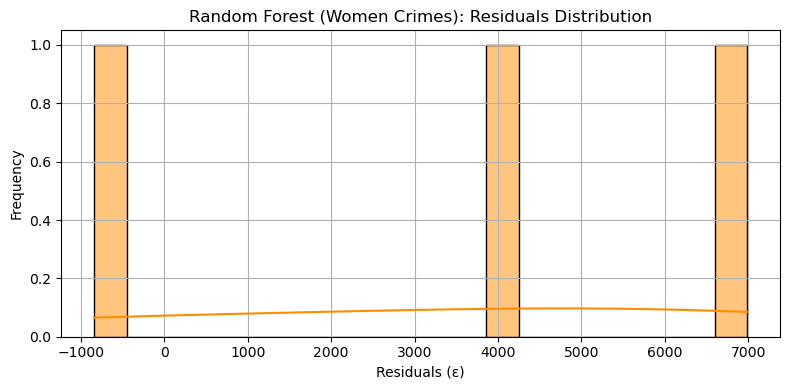

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=20, kde=True, color="darkorange", edgecolor="black")
plt.title("Random Forest (Women Crimes): Residuals Distribution")
plt.xlabel("Residuals (ε)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


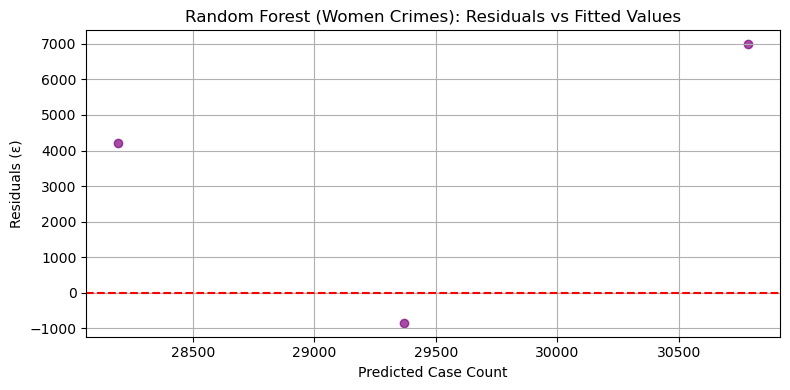

In [7]:
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, color="purple", alpha=0.7)
plt.axhline(y=0, linestyle='--', color='red')
plt.title("Random Forest (Women Crimes): Residuals vs Fitted Values")
plt.xlabel("Predicted Case Count")
plt.ylabel("Residuals (ε)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd


road_df = pd.read_csv("kerala_road_accident_trend_2016_2025.csv")

road_df["Year"] = road_df["Year"].astype(str).str.extract(r"(\d{4})").astype(float)
road_df = road_df.dropna().astype({"Year": int})


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

X = road_df[["Year"]]
y = road_df["No. of accidents"]


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
xgb = XGBRegressor(objective="reg:squarederror", random_state=42).fit(X_train, y_train)

lr_score = r2_score(y_test, lr.predict(X_test))
rf_score = r2_score(y_test, rf.predict(X_test))
xgb_score = r2_score(y_test, xgb.predict(X_test))

print(f"Linear Regression R² Score: {lr_score:.2f}")
print(f"Random Forest R² Score:    {rf_score:.2f}")
print(f"XGBoost R² Score:          {xgb_score:.2f}")


Linear Regression R² Score: -2.35
Random Forest R² Score:    -0.04
XGBoost R² Score:          0.76


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


road_df = pd.read_csv("kerala_road_accident_trend_2016_2025.csv")
women_df = pd.read_csv("kerala_women_crime_summary_2016_2025.csv")
children_df = pd.read_csv("kerala_children_crime_summary_2016_2025.csv")
scst_df = pd.read_csv("kerala_sc_st_crime_summary_2016_2025.csv")

population_data = {
    2016: 35400000, 2017: 35700000, 2018: 36000000, 2019: 36300000,
    2020: 36700000, 2021: 37000000, 2022: 37400000, 2023: 37800000,
    2024: 38000000, 2025: 38200000
}

def evaluate_model(df, value_col, group_col=None):
    if group_col:  # Wide to long format
        df = df.melt(id_vars=[group_col], var_name="Year", value_name=value_col)
    df["Year"] = df["Year"].astype(str).str.extract(r"(\d{4})").astype(float)
    df = df.dropna()
    df["Year"] = df["Year"].astype(int)
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna()
    df_agg = df.groupby("Year")[value_col].sum().reset_index()
    
    X = df_agg[["Year"]]
    y = df_agg[value_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

    lr = LinearRegression().fit(X_train, y_train)
    rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
    xgb = XGBRegressor(objective="reg:squarederror", random_state=42).fit(X_train, y_train)

    return {
        "Linear Regression": round(r2_score(y_test, lr.predict(X_test)), 2),
        "Random Forest": round(r2_score(y_test, rf.predict(X_test)), 2),
        "XGBoost": round(r2_score(y_test, xgb.predict(X_test)), 2)
    }

scores = {
    "Road Accidents": evaluate_model(road_df, "No. of accidents"),
    "Women Crimes": evaluate_model(women_df, "Cases", group_col="Crime Heads"),
    "Children Crimes": evaluate_model(children_df, "Cases", group_col="Crime Heads"),
    "SC/ST Crimes": evaluate_model(scst_df, "Cases", group_col="Crime Heads")
}

accuracy_df = pd.DataFrame(scores).T.reset_index().rename(columns={"index": "Category"})
accuracy_df



,Category,Linear Regression,Random Forest,XGBoost
0,Road Accidents,-2.35,-0.04,0.76
1,Women Crimes,-3.27,-0.56,-0.23
2,Children Crimes,-0.45,0.79,-0.11
3,SC/ST Crimes,-9.71,-1.99,0.34


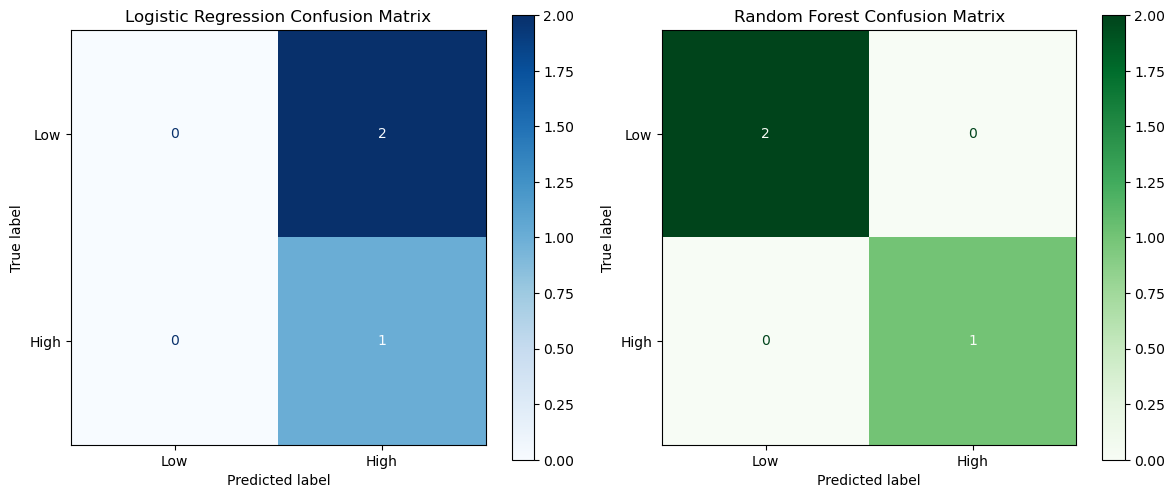

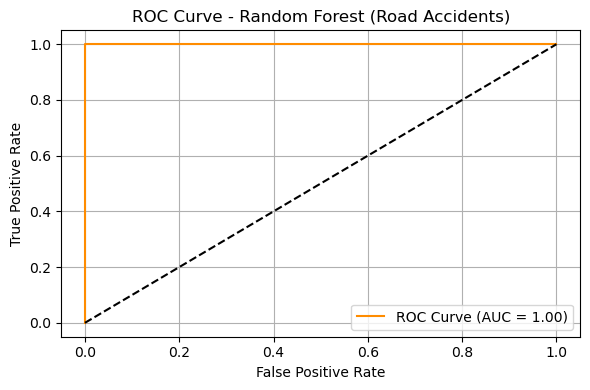

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("kerala_road_accident_trend_2016_2025.csv")
df["Year"] = df["Year"].astype(str).str.extract(r"(\d{4})").astype(int)
df["No. of accidents"] = pd.to_numeric(df["No. of accidents"], errors="coerce")

threshold = df["No. of accidents"].median()
df["High Crime"] = (df["No. of accidents"] > threshold).astype(int)

X = df[["Year"]]
y = df["High Crime"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_model = LogisticRegression().fit(X_train, y_train)
rf_model = RandomForestClassifier(random_state=42).fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log), display_labels=["Low", "High"]).plot(ax=ax[0], cmap='Blues')
ax[0].set_title("Logistic Regression Confusion Matrix")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=["Low", "High"]).plot(ax=ax[1], cmap='Greens')
ax[1].set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Road Accidents)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
